In [1]:
!pip install roboflow ultralytics

from roboflow import Roboflow
rf = Roboflow(api_key="aUkHvLXqn5rDJAj8qOrU")
project = rf.workspace("priscas-workspace").project("fabric-defect-detection-pemgj-dbzw2")
version = project.version(2)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fabric-defect-detection-2 in yolov11:: 100%|██████████| 2958/2958 [00:00<00:00, 4646.47it/s]


In [2]:
import os

print(f"Dataset path: {dataset.location}")


yaml_path = os.path.join(dataset.location, "data.yaml")
print(f"\nContenu data.yaml:")
with open(yaml_path, 'r') as f:
    print(f.read())

Dataset path: /content/fabric-defect-detection-2

Contenu data.yaml:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['0', '1']

roboflow:
  workspace: priscas-workspace
  project: fabric-defect-detection-pemgj-dbzw2
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/priscas-workspace/fabric-defect-detection-pemgj-dbzw2/dataset/2


In [3]:
import os
import glob

results = glob.glob('/content/**/results.png', recursive=True)
print("Fichiers trouvés :")
for r in results:
    print(r)

Fichiers trouvés :


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="aUkHvLXqn5rDJAj8qOrU")
project = rf.workspace("priscas-workspace").project("fabric-defect-detection-pemgj-dbzw2")
dataset = project.version(2).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [5]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
results = model.train(
    data='/content/fabric-defect-detection-2/data.yaml',
    epochs=50,
    imgsz=640,
    project='/content/dataset/runs/detect',
    name='jeans_defect_v112'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fabric-defect-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [6]:
import glob
files = glob.glob('/content/dataset/runs/detect/**/results.png', recursive=True)
print(files)

['/content/dataset/runs/detect/jeans_defect_v112/results.png']


In [7]:
from roboflow import Roboflow
rf = Roboflow(api_key="aUkHvLXqn5rDJAj8qOrU")
project = rf.workspace("priscas-workspace").project("fabric-defect-detection-pemgj-dbzw2")
dataset = project.version(2).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [8]:
from google.colab import files
import glob

dossier = glob.glob('/content/dataset/runs/detect/**/results.png', recursive=True)[0]
dossier = dossier.replace('/results.png', '')
print(f"Dossier : {dossier}")

files.download(f'{dossier}/results.png')
files.download(f'{dossier}/confusion_matrix.png')

Dossier : /content/dataset/runs/detect/jeans_defect_v112


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from roboflow import Roboflow
rf = Roboflow(api_key="aUkHvLXqn5rDJAj8qOrU")
project = rf.workspace("priscas-workspace").project("fabric-defect-detection-pemgj-dbzw2")
dataset = project.version(2).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



image 1/1 /content/fabric-defect-detection-2/test/images/1334_jpg.rf.532819ce5d2098bc43a27ed4c4abc05b.jpg: 640x640 1 0, 9.2ms
Speed: 2.0ms preprocess, 9.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


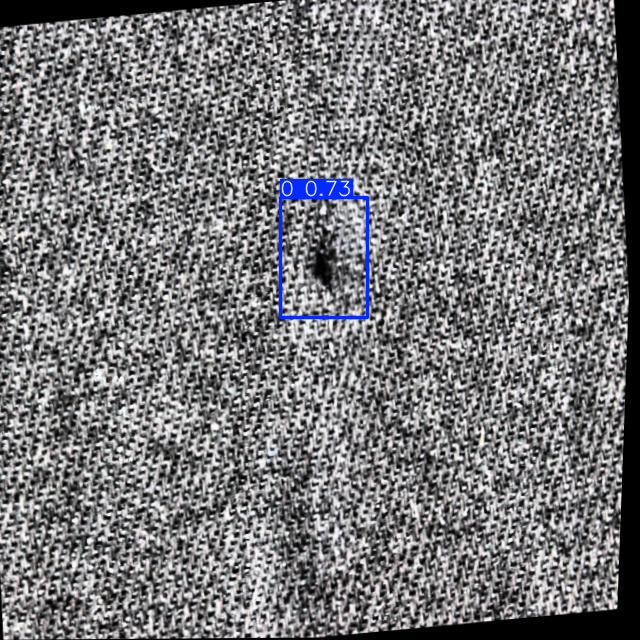

In [13]:
import os
test_images = os.listdir('/content/fabric-defect-detection-2/test/images/')
test_image = f'/content/fabric-defect-detection-2/test/images/{test_images[0]}'
results = model(test_image, conf=0.5)
results[0].show()

## Final Task

### Subtask:
Confirm that the dataset has been successfully extracted to /content/nouveau_dataset.


## Summary:

### Q&A
*   **Has the dataset been successfully extracted to `/content/nouveau_dataset`?**
    Yes, the `D.v1i.yolo26.zip` dataset was successfully extracted to `/content/nouveau_dataset`.
*   **Is `data.yaml` present in the root of the extracted directory?**
    Yes, `data.yaml` was found at `/content/nouveau_dataset/data.yaml`, and its content was successfully read and displayed.

### Data Analysis Key Findings
*   Google Drive was successfully mounted, allowing access to the dataset zip file.
*   The `D.v1i.yolo26.zip` archive was extracted without issues to the specified directory, `/content/nouveau_dataset`.
*   The crucial configuration file, `data.yaml`, was confirmed to be present in the root of the extracted directory (`/content/nouveau_dataset/data.yaml`).

### Insights or Next Steps
*   The successful extraction and verification of `data.yaml` indicate that the dataset is ready for further processing or model training.
*   Proceed with loading the dataset using `data.yaml` to configure the next steps, such as data preprocessing or model initialization.


# Task
Initialize and train the YOLO model using the 'yolo11n.pt' weights and the dataset located at `/content/nouveau_dataset/data.yaml` for 50 epochs, with an image size of 640. The training results will be saved in `/content/runs/detect/nouveau_modele_entrainement`.

## Initialize YOLO Model

### Subtask:
Initialize the YOLO model using the 'yolo11n.pt' weights.


**Reasoning**:
To initialize the YOLO model as instructed, I will import the YOLO class from ultralytics and then create an instance of the model using 'yolo11n.pt' weights.



In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
print("YOLO model initialized with 'yolo11n.pt' weights.")

YOLO model initialized with 'yolo11n.pt' weights.


**Reasoning**:
The YOLO model has been successfully initialized. The next step is to train the model using the provided dataset and parameters, as outlined in the main task. This involves calling the `train` method on the initialized model with the path to `data.yaml`, the number of epochs, image size, project directory, and training name.



In [ ]:
from ultralytics import YOLO

# Initialize the YOLO model (yolo11n.pt was downloaded earlier)
model = YOLO('yolo11n.pt')

# Train the model using the extracted dataset
results = model.train(
    data='/content/nouveau_dataset/data.yaml', # Path to the data.yaml file in the extracted dataset
    epochs=50,
    imgsz=640,
    project='/content/runs/detect', # Directory where training results will be saved
    name='nouveau_modele_entrainement' # Name for this specific training run
)

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/nouveau_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nouveau_modele_entrainement3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

## Final Task

### Subtask:
Confirm the successful completion of the YOLO model training.


## Summary:

### Data Analysis Key Findings

*   The YOLO model was successfully initialized using the 'yolo11n.pt' pre-trained weights.
*   Model training was completed for 50 epochs using the dataset located at `/content/nouveau_dataset/data.yaml` with an image size of 640 pixels.
*   A warning was noted during training regarding a discrepancy between box and segment counts, resulting in only bounding box annotations being used.
*   The trained model achieved the following validation metrics: Precision (Box P) of 0.705, Recall (R) of 0.614, mAP50 of 0.626, and mAP50-95 of 0.265.
*   All training results, including the best and last model weights, were saved to the specified directory: `/content/runs/detect/nouveau_modele_entrainement3`.

### Insights or Next Steps

*   Investigate the "box and segment counts" warning to understand its implications on model performance and determine if segment annotations should be rectified or if bounding box-only training is sufficient for the task.
*   Evaluate the model's performance on a separate test set and consider fine-tuning hyperparameters or increasing training epochs if the current mAP50-95 of 0.265 is not meeting performance requirements for the specific application.


# Task
**User provided command:** `USER_RESPONSE_APPROVE`

## Locate Training Results Images

### Subtask:
Locate the 'results.png' and 'confusion_matrix.png' files within the training results directory.

### Reasoning:
To find the training results images, I will use the `glob` module to search for `results.png` and `confusion_matrix.png` within the `/content/runs/detect/nouveau_modele_entrainement3` directory. This will confirm their existence and provide their full paths for display.

## Display Training Results

### Subtask:
Display the 'results.png' and 'confusion_matrix.png' images to visually inspect the training performance and confusion matrix.

### Reasoning:
To visualize the training results, I will use `IPython.display.Image` to render the `results.png` and `confusion_matrix.png` files directly in the notebook. This allows for immediate assessment of the model's performance during training.


## Locate Training Results Images

### Subtask:
Locate the 'results.png' and 'confusion_matrix.png' files within the training results directory.


**Reasoning**:
To locate the specified image files, I will use the `glob` module to search for them within the training results directory and print their paths.



In [ ]:
import glob
import os

# Define the training results directory
training_results_dir = '/content/runs/detect/nouveau_modele_entrainement3'

# Locate results.png
results_png_path_list = glob.glob(os.path.join(training_results_dir, 'results.png'))
results_png_path = results_png_path_list[0] if results_png_path_list else 'Not found'

# Locate confusion_matrix.png
confusion_matrix_png_path_list = glob.glob(os.path.join(training_results_dir, 'confusion_matrix.png'))
confusion_matrix_png_path = confusion_matrix_png_path_list[0] if confusion_matrix_png_path_list else 'Not found'

# Print the paths
print(f"Path to results.png: {results_png_path}")
print(f"Path to confusion_matrix.png: {confusion_matrix_png_path}")

Path to results.png: /content/runs/detect/nouveau_modele_entrainement3/results.png
Path to confusion_matrix.png: /content/runs/detect/nouveau_modele_entrainement3/confusion_matrix.png


**Reasoning**:
The 'results.png' and 'confusion_matrix.png' files have been located. Now, I will display these images using `IPython.display.Image` to allow for visual inspection of the training performance and confusion matrix, as per the subtask's instructions.




Displaying results.png:


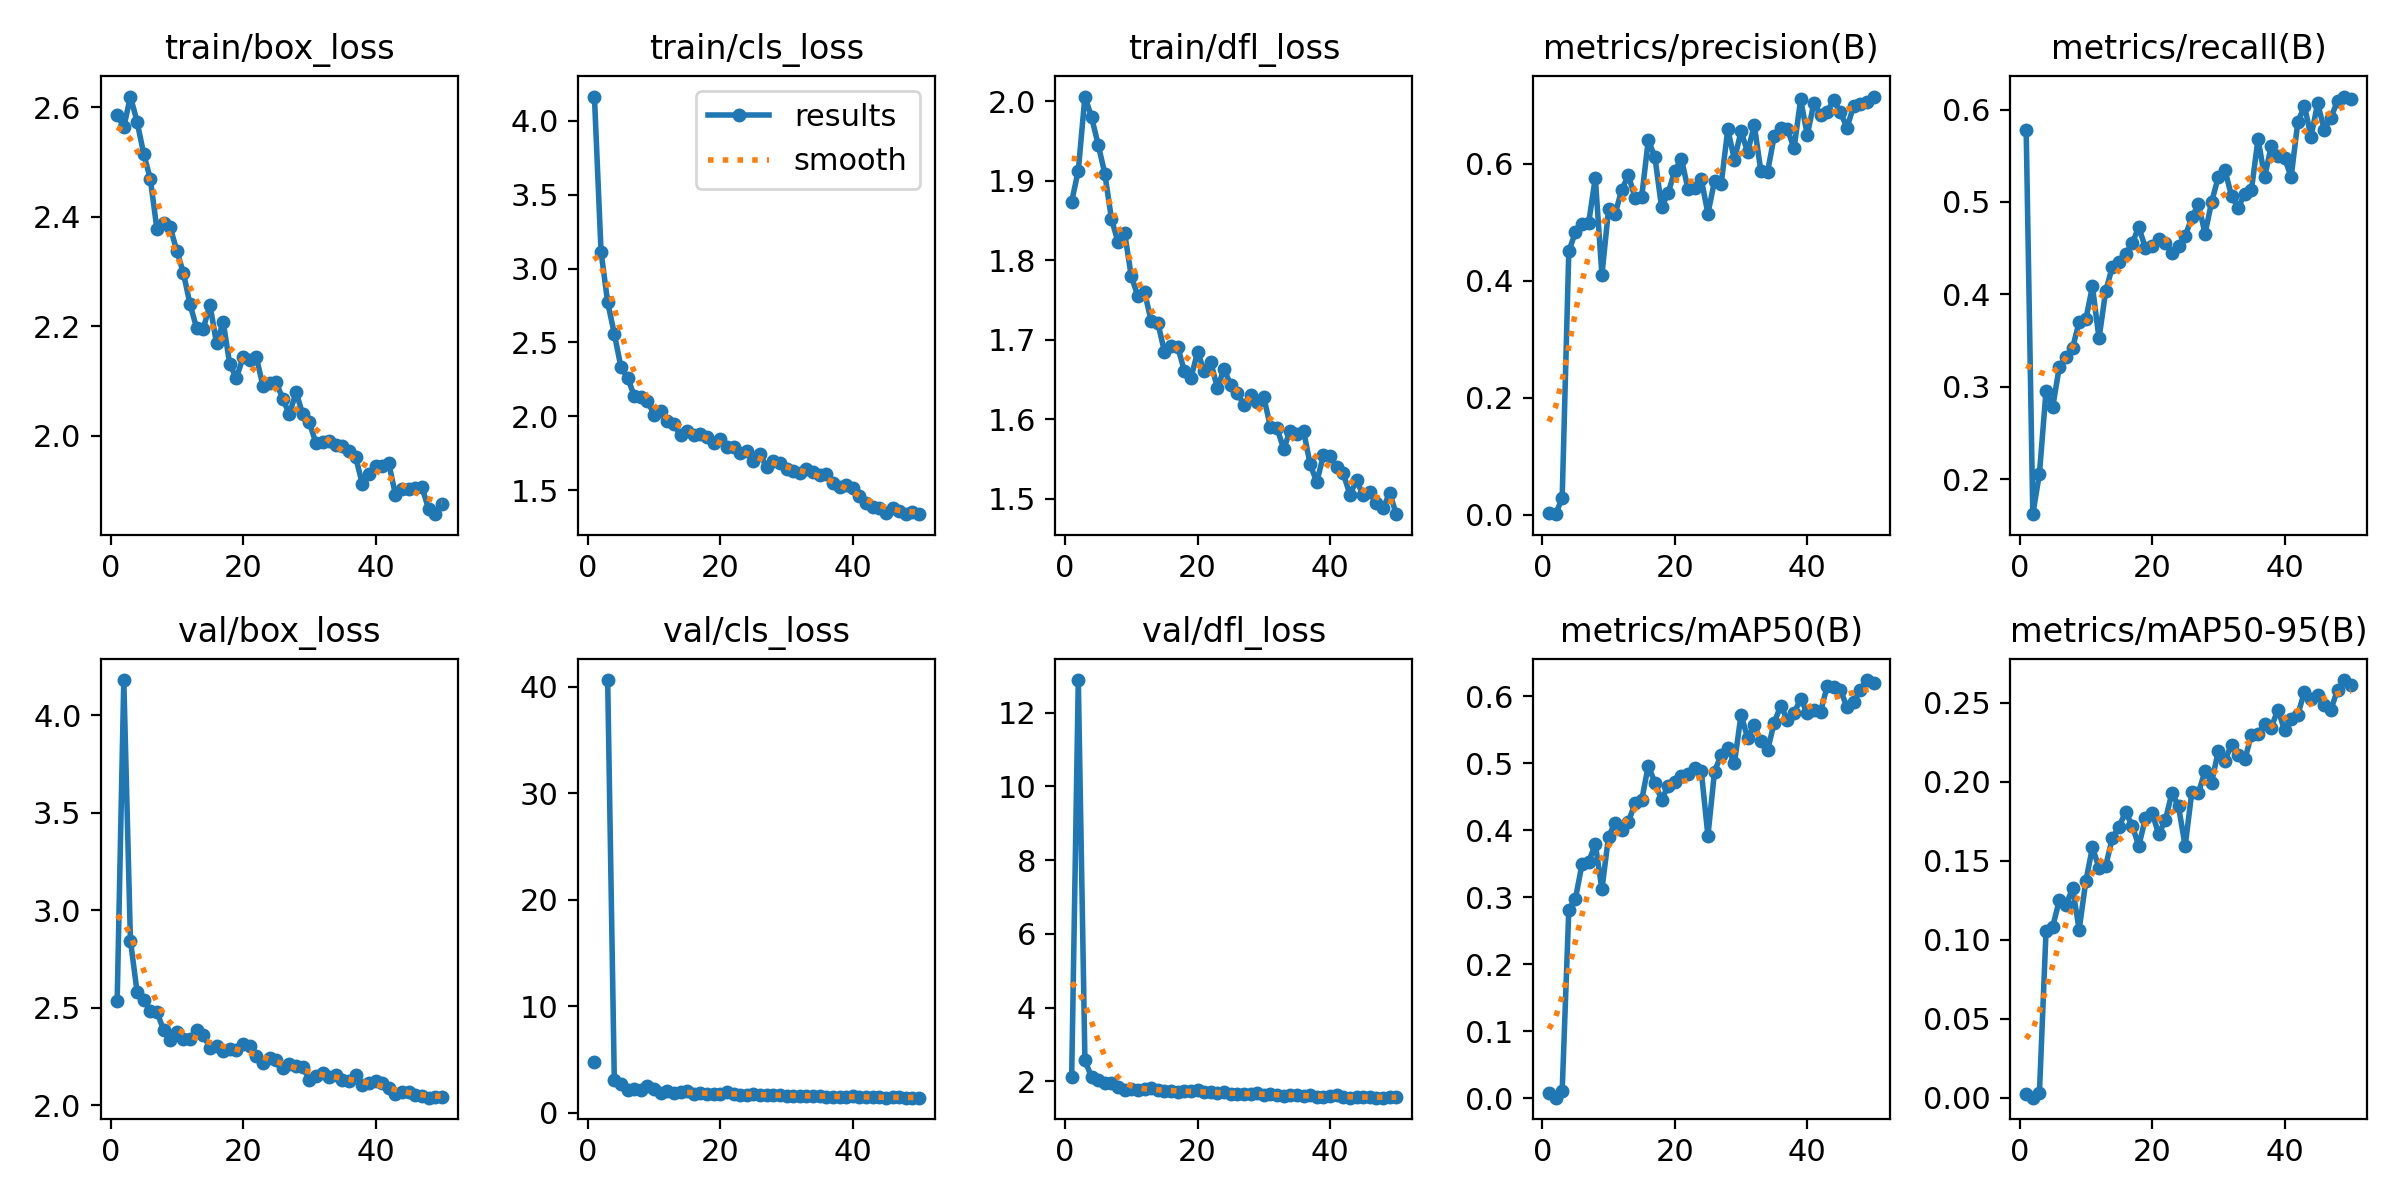


Displaying confusion_matrix.png:


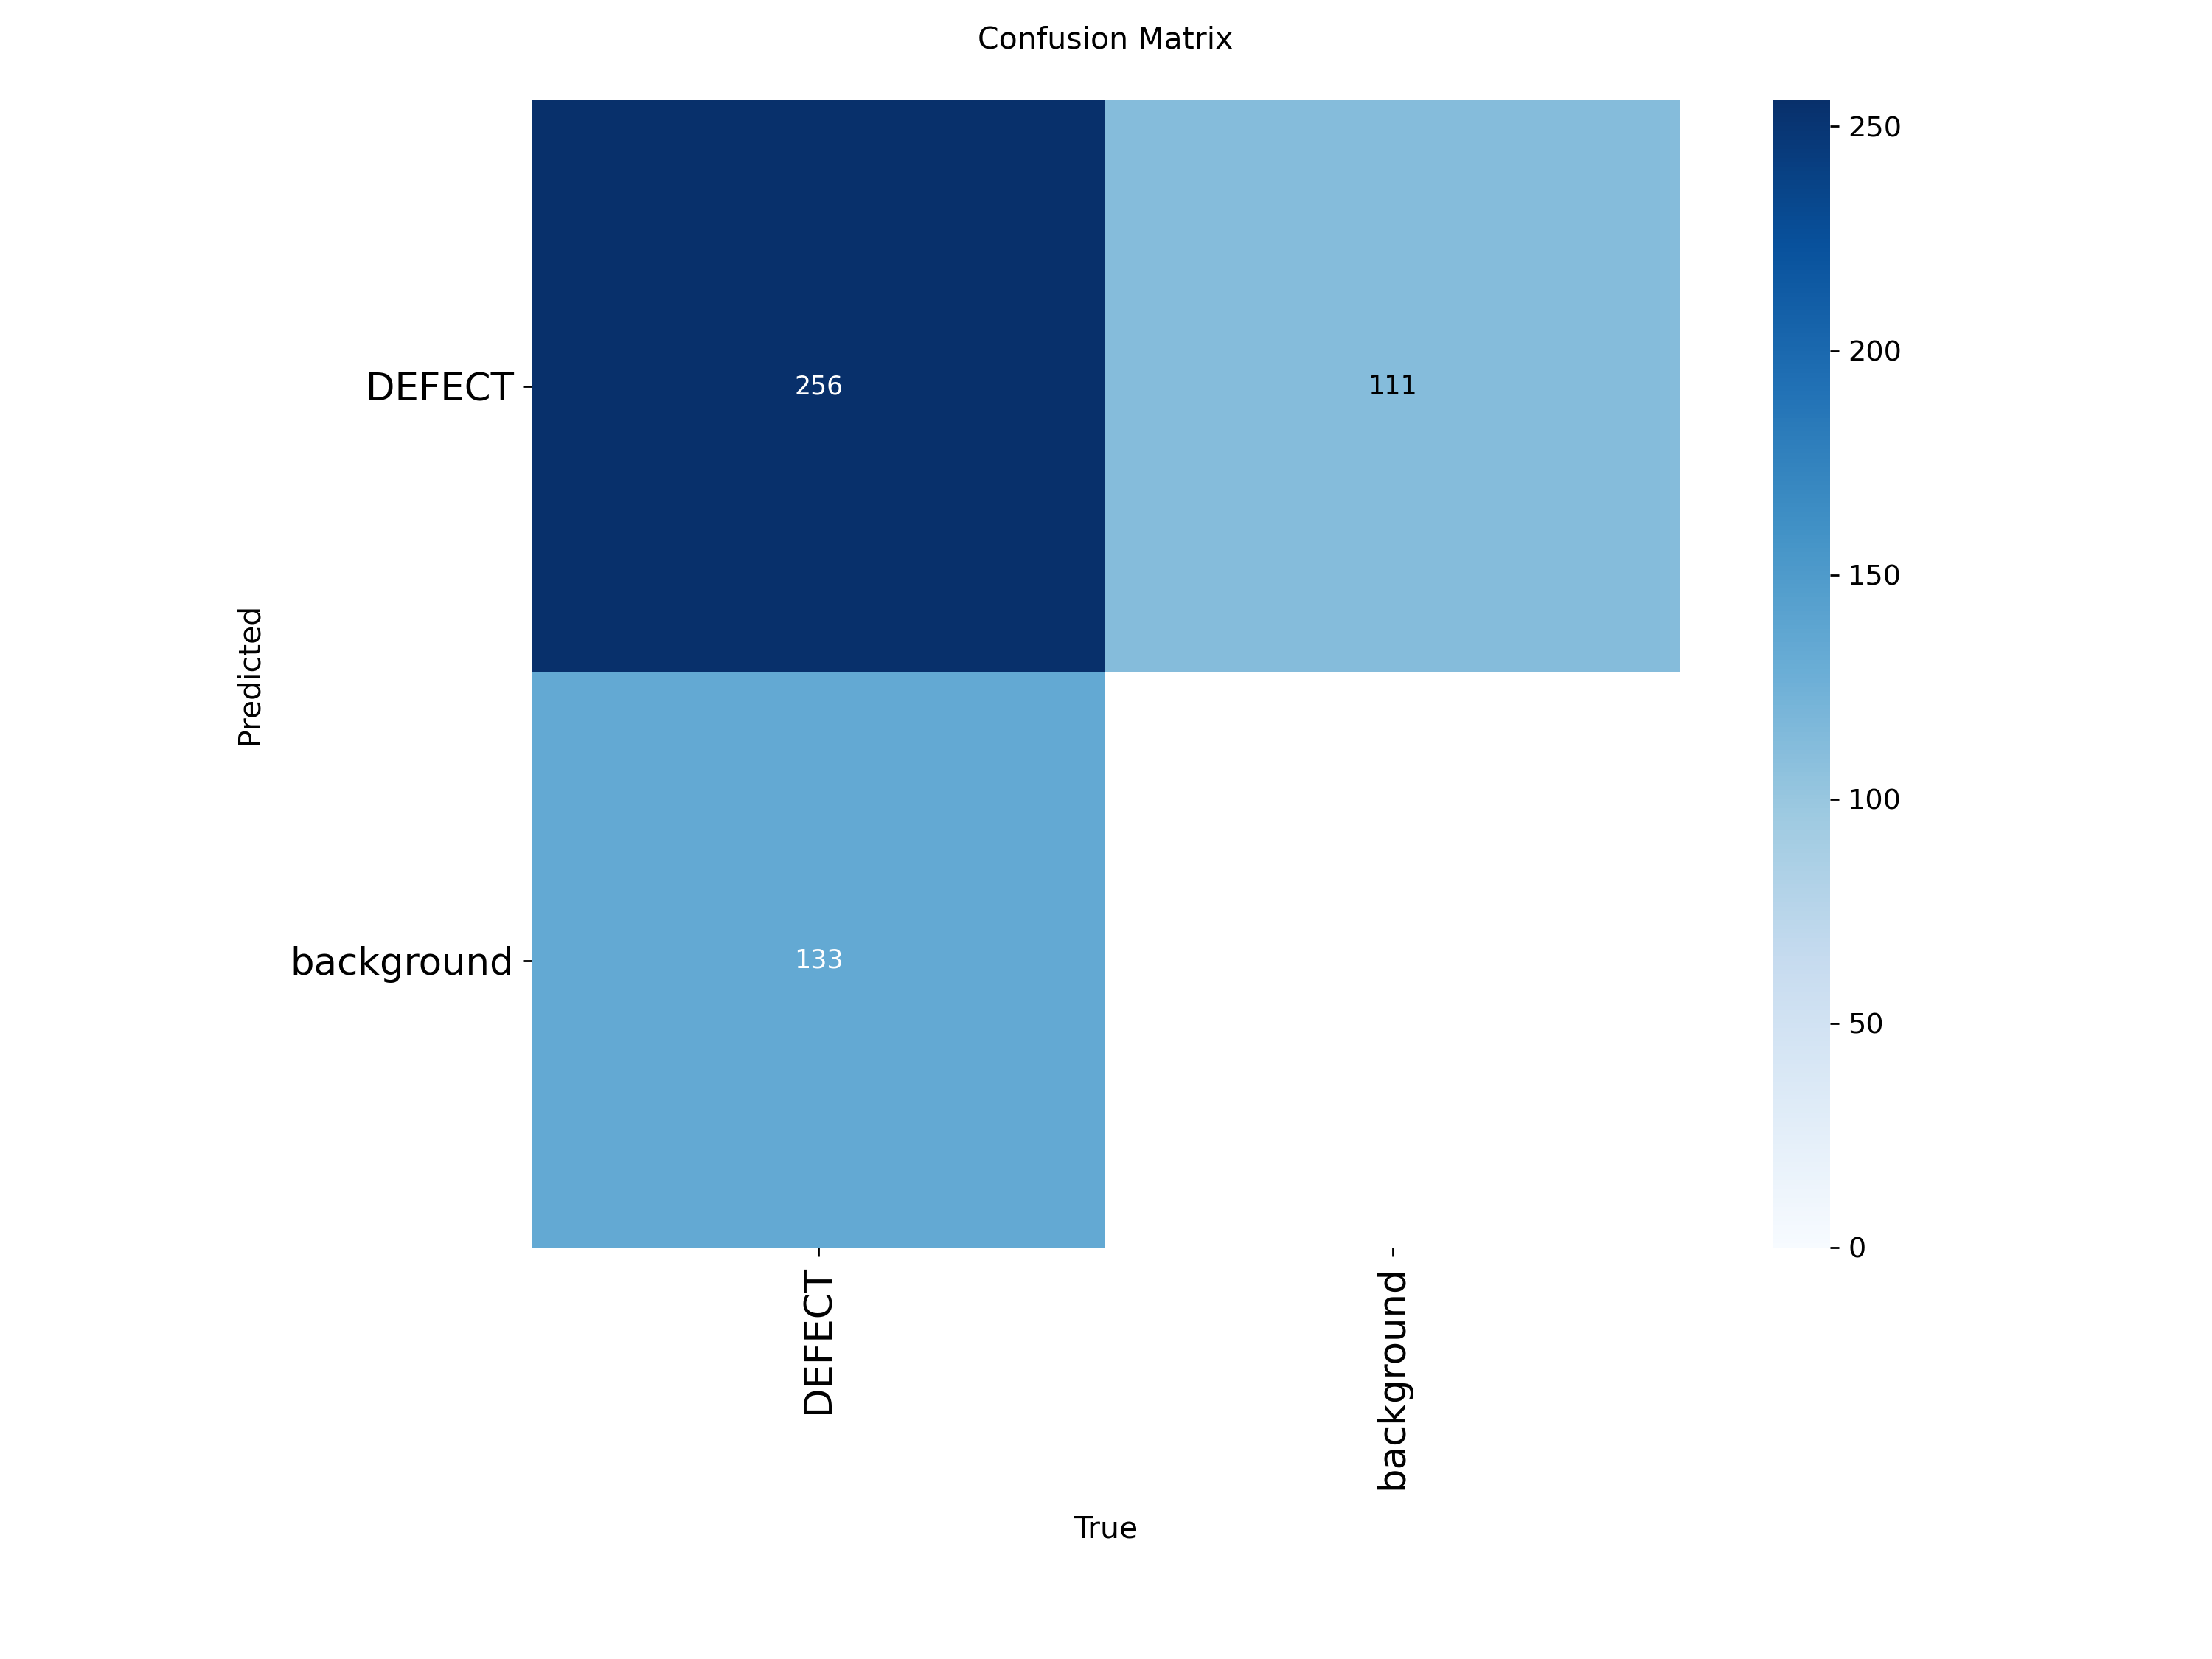

In [ ]:
from IPython.display import Image, display

# Display results.png
if os.path.exists(results_png_path):
    print("\nDisplaying results.png:")
    display(Image(filename=results_png_path))
else:
    print(f"results.png not found at {results_png_path}")

# Display confusion_matrix.png
if os.path.exists(confusion_matrix_png_path):
    print("\nDisplaying confusion_matrix.png:")
    display(Image(filename=confusion_matrix_png_path))
else:
    print(f"confusion_matrix.png not found at {confusion_matrix_png_path}")

## Final Task

### Subtask:
Summarize the visualized training results.


## Summary:

### Data Analysis Key Findings

*   The `results.png` and `confusion_matrix.png` files were successfully located in the `/content/runs/detect/nouveau_modele_entrainement3` directory.
*   Both image files were successfully displayed, confirming their presence and readiness for visual inspection of the training performance and confusion matrix.

### Insights or Next Steps

*   Proceed with the visual analysis of the displayed `results.png` and `confusion_matrix.png` to evaluate the model's training performance and classification accuracy.
